# Arabic Sign Language Alphabet Classification

This notebook was completed as a master's-level course project for **Deep Learning (CIS 735)**.

It compares fully connected neural networks and convolutional neural networks across several activation functions and optimizers using the Arabic Alphabets Sign Language Dataset (ArASL). Recorded outputs from the original course environment are preserved for reference. Re-running the experiments can produce small numerical differences across TensorFlow versions and hardware.


In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split


In [ ]:
# Resolve project paths whether Jupyter starts at the repository root or inside notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "README.md").is_file():
    PROJECT_ROOT = next(
        (parent for parent in PROJECT_ROOT.parents if (parent / "README.md").is_file()),
        PROJECT_ROOT,
    )

DATA_ROOT = Path(
    os.getenv("ARASL_DATA_DIR", PROJECT_ROOT / "data" / "raw")
).expanduser()
if not DATA_ROOT.is_absolute():
    DATA_ROOT = PROJECT_ROOT / DATA_ROOT

IMAGES_DIR = DATA_ROOT / "ArASL_Database_54K_Final"
LABELS_PATH = DATA_ROOT / "ArSL_Data_Labels.csv"
ASSETS_DIR = PROJECT_ROOT / "assets"

SEED = 123
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


In [ ]:
# Build a table containing every image path from the 32 class folders.
if not IMAGES_DIR.is_dir():
    raise FileNotFoundError(
        f"Image directory not found: {IMAGES_DIR}. Follow data/README.md to install the dataset."
    )

image_paths = sorted(
    str(path)
    for path in IMAGES_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)
if not image_paths:
    raise FileNotFoundError(f"No images were found under {IMAGES_DIR}.")

df = pd.DataFrame({"Path": image_paths})
df.shape


In [ ]:
# Read the official label file supplied with the Mendeley dataset.
if not LABELS_PATH.is_file():
    raise FileNotFoundError(
        f"Label file not found: {LABELS_PATH}. Follow data/README.md to install the dataset."
    )

labels = pd.read_csv(LABELS_PATH)
required_columns = {"File_Name", "Class"}
missing_columns = required_columns.difference(labels.columns)
if missing_columns:
    raise ValueError(f"Label CSV is missing required columns: {sorted(missing_columns)}")
labels.drop("#", axis=1, inplace=True, errors="ignore")
labels.head()


In [5]:
# Create temp path contain the letter and it's number 
# by getting last index in path columns after seperate it by '/'  
df['temp_path'] = df['Path'].apply(lambda x: Path(x).name)

# Merge Paths with their labels based on temp path column from data and File Name column from labels file
df2 = pd.merge(df, labels, left_on='temp_path', right_on='File_Name')

# Drop unnecessary columns
df2.drop(['temp_path', 'File_Name'], axis=1, inplace=True)


In [6]:
# Convert string labels to numeric labels
# Get the unique classes
classes = np.unique(df2.Class).tolist()
if len(classes) != 32:
    raise ValueError(f"Expected 32 classes, found {len(classes)}. Check the dataset layout.")

# Create list with classes number
values = list(range(len(classes)))

# Create a dictionary contain the class and it's numeric value
dic = dict(zip(classes, values))

df2['n_class'] = df2.Class.map(dic).values
df2.drop('Class', axis=1,inplace=True)
df2.head(2)

,Path,n_class
0,/ArASL_Database_54K_Final/...,8
1,/ArASL_Database_54K_Final/...,8


In [7]:
# Data Shuffling
df2 = df2.sample(frac=1, random_state=123).reset_index(drop=True)

# Split the data into training set and validation set
train, valid = train_test_split(df2, test_size=0.2, random_state=123, shuffle=True, stratify=df2.n_class)

# Seperate the path and class and create two dataframe contain training and validation data
train_ds = tf.data.Dataset.from_tensor_slices((train.Path,train.n_class))
valid_ds = tf.data.Dataset.from_tensor_slices((valid.Path,valid.n_class))

2022-11-26 23:11:27.864474: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-26 23:11:27.952182: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-26 23:11:27.953014: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2022-11-26 23:11:27.955887: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

In [8]:
# Create preprocessing function that Read the image and Resize it as specific size
def preprocess(path,label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img,[224,224])
    img = img /255.0
    return img, tf.cast(label, tf.int32)

In [9]:
# Apply preprocessing function on the taining dataframe and validation dataframe
train_ds = train_ds.map(preprocess).shuffle(128, seed=SEED).batch(64).prefetch(tf.data.AUTOTUNE)
valid_ds = valid_ds.map(preprocess).batch(64).prefetch(tf.data.AUTOTUNE)

#   ***Question One***

#### Creating Fully connected neural network consists of an Input layer , 2 Hidden layer and output layer ..  with "Relu" activation function .

In [9]:
model_s = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_s.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 150528)            0         
_________________________________________________________________
dense (Dense)                (None, 128)               19267712  
_________________________________________________________________
dense_1 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_2 (Dense)              (None, 32)                2080      
Total params: 19,278,048
Trainable params: 19,278,048
Non-trainable params: 0
_________________________________________________________________


### Compile the model using sparse_categorical_crossentropy and Adam optimizer


In [10]:
model_s.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               metrics=['accuracy'])

In [11]:
# Training the model with 10 epochs
k = model_s.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10


2022-11-26 17:08:04.336039: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


676/676 [==============================] - 107s 155ms/step - loss: 5.2515 - accuracy: 0.0419 - val_loss: 3.3743 - val_accuracy: 0.0513
Epoch 2/10
676/676 [==============================] - 62s 92ms/step - loss: 3.3252 - accuracy: 0.0671 - val_loss: 3.2659 - val_accuracy: 0.0777
Epoch 3/10
676/676 [==============================] - 64s 94ms/step - loss: 3.2185 - accuracy: 0.0944 - val_loss: 3.1725 - val_accuracy: 0.1097
Epoch 4/10
676/676 [==============================] - 62s 91ms/step - loss: 3.1158 - accuracy: 0.1286 - val_loss: 3.0689 - val_accuracy: 0.1412
Epoch 5/10
676/676 [==============================] - 63s 92ms/step - loss: 3.0089 - accuracy: 0.1606 - val_loss: 2.9775 - val_accuracy: 0.1700
Epoch 6/10
676/676 [==============================] - 62s 92ms/step - loss: 2.9652 - accuracy: 0.1739 - val_loss: 2.9639 - val_accuracy: 0.1759
Epoch 7/10
676/676 [==============================] - 62s 92ms/step - loss: 2.9142 - accuracy: 0.1889 - val_loss: 2.9385 - val_accuracy: 0.1830
E

### The below figures shows that the training accuracy and validation accuracy through training are increasing, but there are suddenly decreasing in the accuracy then it complete increasing. There is no high gap between trianing accuracy line and validation line which mean that the model need more training or make the network more depth

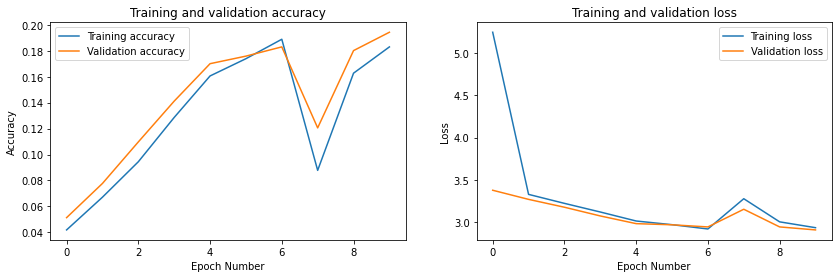

In [13]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

## Q1 -3 We will check the impact of the network depth by increasing number of hidden layer by 1 hidden layer more.

In [14]:
model_s = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_s.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_3 (Dense)              (None, 128)               19267712  
_________________________________________________________________
dense_4 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_5 (Dense)              (None, 64)                4160      
_________________________________________________________________
dense_6 (Dense)              (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [16]:
model_s.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               metrics=['accuracy'])

In [17]:
# Training the model with 10 epochs
k = model_s.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 63s 93ms/step - loss: 4.5763 - accuracy: 0.0617 - val_loss: 3.1093 - val_accuracy: 0.1322
Epoch 2/10
676/676 [==============================] - 63s 93ms/step - loss: 2.8910 - accuracy: 0.1667 - val_loss: 2.5707 - val_accuracy: 0.2375
Epoch 3/10
676/676 [==============================] - 63s 93ms/step - loss: 2.5152 - accuracy: 0.2560 - val_loss: 2.5005 - val_accuracy: 0.2731
Epoch 4/10
676/676 [==============================] - 63s 93ms/step - loss: 2.2550 - accuracy: 0.3217 - val_loss: 2.3503 - val_accuracy: 0.2923
Epoch 5/10
676/676 [==============================] - 62s 91ms/step - loss: 2.0688 - accuracy: 0.3725 - val_loss: 2.2245 - val_accuracy: 0.3393
Epoch 6/10
676/676 [==============================] - 62s 91ms/step - loss: 1.9467 - accuracy: 0.4050 - val_loss: 2.3677 - val_accuracy: 0.3286
Epoch 7/10
676/676 [==============================] - 63s 92ms/step - loss: 1.8508 - accuracy: 0.4348 - val_loss: 1.7849 - val_accuracy:

### The below figures shows that there is no gap training line and validation line which mean that the model need more training. And the second figure shows the training loss and validation loss are still decreasing 
### It was observed that when one hidden layer added that accuracy value began at 16% instead of 4% as we noticed in the first neural network.
### The accuracy value reached 51% while it reached only 18% in the first experiment.

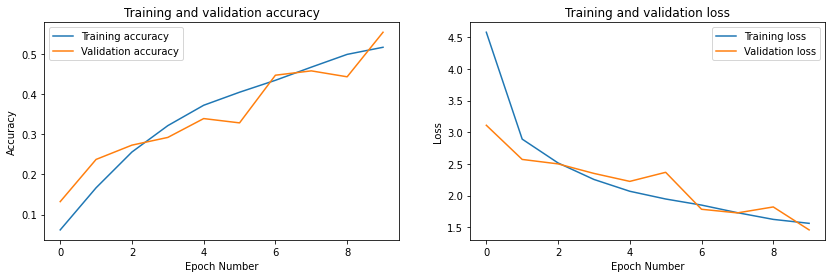

In [18]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### 

### Q1 2- Assses the impact of RMSProp optimizer with Relu activation function

In [19]:
model_rms = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_rms.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_2 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_7 (Dense)              (None, 128)               19267712  
_________________________________________________________________
dense_8 (Dense)              (None, 64)                8256      
_________________________________________________________________
dense_9 (Dense)              (None, 64)                4160      
_________________________________________________________________
dense_10 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [21]:
model_rms.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
               metrics=['accuracy'])

In [22]:
# Training the model with 10 epochs
k = model_rms.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 66s 97ms/step - loss: 8.8926 - accuracy: 0.0335 - val_loss: 3.4617 - val_accuracy: 0.0391
Epoch 2/10
676/676 [==============================] - 65s 95ms/step - loss: 3.4609 - accuracy: 0.0391 - val_loss: 3.4600 - val_accuracy: 0.0391
Epoch 3/10
676/676 [==============================] - 51s 75ms/step - loss: 3.4602 - accuracy: 0.0391 - val_loss: 3.4598 - val_accuracy: 0.0391
Epoch 4/10
676/676 [==============================] - 65s 96ms/step - loss: 3.4600 - accuracy: 0.0391 - val_loss: 3.4597 - val_accuracy: 0.0391
Epoch 5/10
676/676 [==============================] - 66s 97ms/step - loss: 3.4600 - accuracy: 0.0391 - val_loss: 3.4597 - val_accuracy: 0.0391
Epoch 6/10
676/676 [==============================] - 64s 95ms/step - loss: 3.4600 - accuracy: 0.0391 - val_loss: 3.4597 - val_accuracy: 0.0391
Epoch 7/10
676/676 [==============================] - 50s 74ms/step - loss: 3.4600 - accuracy: 0.0391 - val_loss: 3.4597 - val_accuracy:

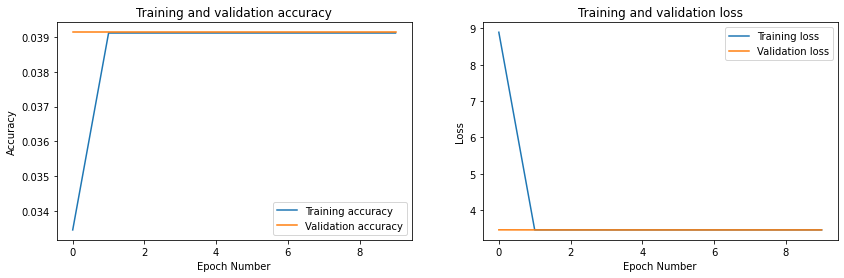

In [23]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 2- Assses the impact of SGD+ Momentum optimizer with Relu activation function

In [24]:
model_sgd = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_sgd.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_3 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_11 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_12 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_13 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_14 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [25]:
model_sgd.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
               metrics=['accuracy'])

In [26]:
# Training the model with 10 epochs
k = model_sgd.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 64s 94ms/step - loss: 3.4280 - accuracy: 0.0551 - val_loss: 3.3778 - val_accuracy: 0.0779
Epoch 2/10
676/676 [==============================] - 48s 71ms/step - loss: 3.3053 - accuracy: 0.1065 - val_loss: 3.2396 - val_accuracy: 0.1378
Epoch 3/10
676/676 [==============================] - 62s 91ms/step - loss: 3.1419 - accuracy: 0.1443 - val_loss: 3.1031 - val_accuracy: 0.1522
Epoch 4/10
676/676 [==============================] - 62s 91ms/step - loss: 2.9576 - accuracy: 0.1828 - val_loss: 2.9409 - val_accuracy: 0.1869
Epoch 5/10
676/676 [==============================] - 62s 91ms/step - loss: 2.7776 - accuracy: 0.2266 - val_loss: 2.7786 - val_accuracy: 0.2123
Epoch 6/10
676/676 [==============================] - 49s 72ms/step - loss: 2.6134 - accuracy: 0.2635 - val_loss: 2.5622 - val_accuracy: 0.2752
Epoch 7/10
676/676 [==============================] - 64s 94ms/step - loss: 2.4705 - accuracy: 0.3004 - val_loss: 2.5360 - val_accuracy:

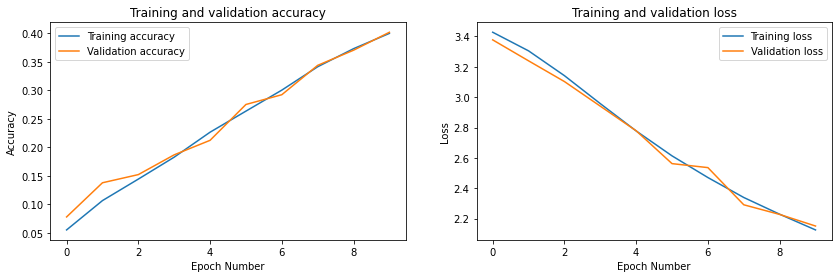

In [27]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Sigmoid activation function with SGD Momentum optimizer

In [28]:
model_sig = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_sig.summary()

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_4 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_15 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_16 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_17 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_18 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [29]:
model_sig.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
               metrics=['accuracy'])

In [30]:
# Training the model with 10 epochs
k = model_sig.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 62s 91ms/step - loss: 3.5554 - accuracy: 0.0350 - val_loss: 3.5193 - val_accuracy: 0.0371
Epoch 2/10
676/676 [==============================] - 63s 93ms/step - loss: 3.5006 - accuracy: 0.0357 - val_loss: 3.4861 - val_accuracy: 0.0351
Epoch 3/10
676/676 [==============================] - 63s 93ms/step - loss: 3.4777 - accuracy: 0.0368 - val_loss: 3.4711 - val_accuracy: 0.0389
Epoch 4/10
676/676 [==============================] - 64s 95ms/step - loss: 3.4672 - accuracy: 0.0369 - val_loss: 3.4641 - val_accuracy: 0.0356
Epoch 5/10
676/676 [==============================] - 53s 78ms/step - loss: 3.4622 - accuracy: 0.0367 - val_loss: 3.4607 - val_accuracy: 0.0367
Epoch 6/10
676/676 [==============================] - 63s 93ms/step - loss: 3.4597 - accuracy: 0.0403 - val_loss: 3.4589 - val_accuracy: 0.0388
Epoch 7/10
676/676 [==============================] - 63s 93ms/step - loss: 3.4584 - accuracy: 0.0394 - val_loss: 3.4579 - val_accuracy:

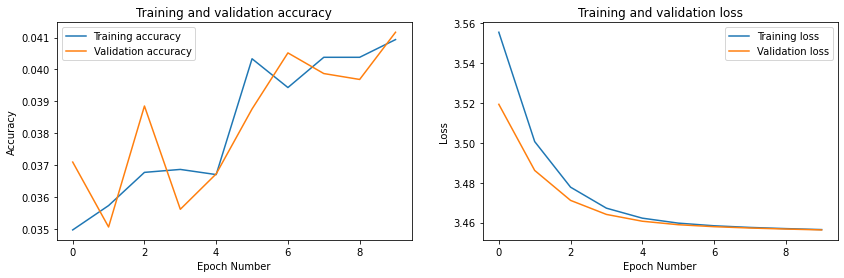

In [31]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Sigmoid activation function with Adam optimizer

In [43]:
model_sig_a = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_sig_a.summary()

Model: "sequential_8"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_8 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_31 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_32 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_33 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_34 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [44]:
model_sig_a.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               metrics=['accuracy'])

In [45]:
# Training the model with 10 epochs
k = model_sig_a.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 66s 97ms/step - loss: 3.4683 - accuracy: 0.0358 - val_loss: 3.4668 - val_accuracy: 0.0391
Epoch 2/10
676/676 [==============================] - 68s 100ms/step - loss: 3.4643 - accuracy: 0.0370 - val_loss: 3.4642 - val_accuracy: 0.0391
Epoch 3/10
676/676 [==============================] - 66s 98ms/step - loss: 3.4631 - accuracy: 0.0371 - val_loss: 3.4622 - val_accuracy: 0.0391
Epoch 4/10
676/676 [==============================] - 69s 101ms/step - loss: 3.4622 - accuracy: 0.0387 - val_loss: 3.4612 - val_accuracy: 0.0391
Epoch 5/10
676/676 [==============================] - 66s 98ms/step - loss: 3.4615 - accuracy: 0.0387 - val_loss: 3.4606 - val_accuracy: 0.0391
Epoch 6/10
676/676 [==============================] - 62s 91ms/step - loss: 3.4612 - accuracy: 0.0386 - val_loss: 3.4603 - val_accuracy: 0.0391
Epoch 7/10
676/676 [==============================] - 62s 91ms/step - loss: 3.4609 - accuracy: 0.0391 - val_loss: 3.4601 - val_accurac

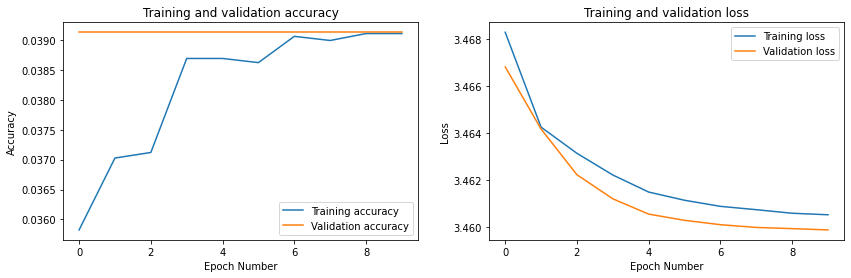

In [46]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Sigmoid activation function with RMSProp optimizer

In [47]:
model_sig_r = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(64, activation='sigmoid'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_sig_r.summary()

Model: "sequential_9"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_9 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_35 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_36 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_37 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_38 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [48]:
model_sig_r.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
               metrics=['accuracy'])

In [49]:
# Training the model with 10 epochs
k = model_sig_r.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 63s 92ms/step - loss: 3.4696 - accuracy: 0.0364 - val_loss: 3.4656 - val_accuracy: 0.0391
Epoch 2/10
676/676 [==============================] - 62s 92ms/step - loss: 3.4652 - accuracy: 0.0367 - val_loss: 3.4642 - val_accuracy: 0.0391
Epoch 3/10
676/676 [==============================] - 62s 92ms/step - loss: 3.4639 - accuracy: 0.0372 - val_loss: 3.4623 - val_accuracy: 0.0391
Epoch 4/10
676/676 [==============================] - 63s 93ms/step - loss: 3.4625 - accuracy: 0.0380 - val_loss: 3.4616 - val_accuracy: 0.0391
Epoch 5/10
676/676 [==============================] - 63s 93ms/step - loss: 3.4616 - accuracy: 0.0382 - val_loss: 3.4607 - val_accuracy: 0.0391
Epoch 6/10
676/676 [==============================] - 63s 94ms/step - loss: 3.4611 - accuracy: 0.0384 - val_loss: 3.4603 - val_accuracy: 0.0391
Epoch 7/10
676/676 [==============================] - 62s 92ms/step - loss: 3.4609 - accuracy: 0.0389 - val_loss: 3.4602 - val_accuracy:

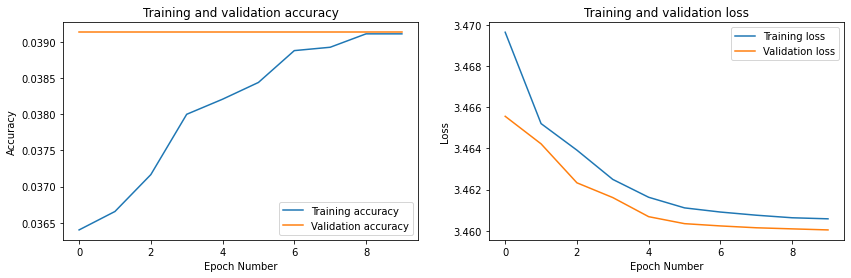

In [50]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Tanh activation function with SGD Momentum optimizer

In [51]:
model_tan = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_tan.summary()

Model: "sequential_10"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_10 (Flatten)         (None, 150528)            0         
_________________________________________________________________
dense_39 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_40 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_41 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_42 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [52]:
model_tan.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
               metrics=['accuracy'])

In [53]:
# Training the model with 10 epochs
k = model_tan.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 64s 95ms/step - loss: 3.3519 - accuracy: 0.0847 - val_loss: 3.2493 - val_accuracy: 0.1177
Epoch 2/10
676/676 [==============================] - 63s 94ms/step - loss: 3.1747 - accuracy: 0.1558 - val_loss: 3.1435 - val_accuracy: 0.1611
Epoch 3/10
676/676 [==============================] - 62s 92ms/step - loss: 3.0558 - accuracy: 0.1986 - val_loss: 3.0135 - val_accuracy: 0.2119
Epoch 4/10
676/676 [==============================] - 63s 93ms/step - loss: 2.9561 - accuracy: 0.2287 - val_loss: 2.9313 - val_accuracy: 0.2401
Epoch 5/10
676/676 [==============================] - 62s 91ms/step - loss: 2.8643 - accuracy: 0.2624 - val_loss: 2.8952 - val_accuracy: 0.2403
Epoch 6/10
676/676 [==============================] - 62s 92ms/step - loss: 2.7795 - accuracy: 0.2851 - val_loss: 2.7894 - val_accuracy: 0.2757
Epoch 7/10
676/676 [==============================] - 62s 91ms/step - loss: 2.7000 - accuracy: 0.3080 - val_loss: 2.6993 - val_accuracy:

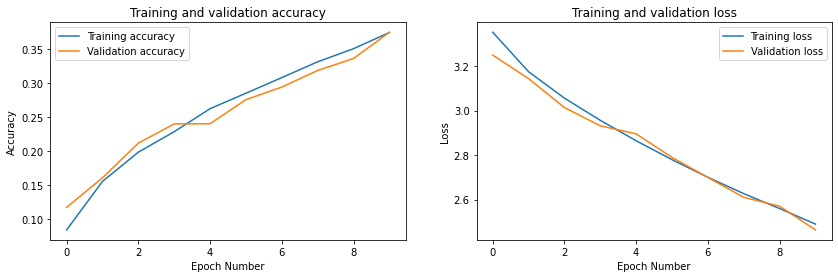

In [54]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Tanh activation function with Adam optimizer

In [55]:
model_tan_a = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_sig.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_7 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_27 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_28 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_29 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_30 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [56]:
model_tan_a.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               metrics=['accuracy'])

In [57]:
# Training the model with 10 epochs
k = model_tan_a.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 63s 92ms/step - loss: 3.4804 - accuracy: 0.0352 - val_loss: 3.4749 - val_accuracy: 0.0389
Epoch 2/10
676/676 [==============================] - 62s 92ms/step - loss: 3.4741 - accuracy: 0.0367 - val_loss: 3.4729 - val_accuracy: 0.0391
Epoch 3/10
676/676 [==============================] - 62s 91ms/step - loss: 3.4725 - accuracy: 0.0362 - val_loss: 3.4747 - val_accuracy: 0.0391
Epoch 4/10
676/676 [==============================] - 62s 91ms/step - loss: 3.4713 - accuracy: 0.0362 - val_loss: 3.4718 - val_accuracy: 0.0391
Epoch 5/10
676/676 [==============================] - 51s 75ms/step - loss: 3.4702 - accuracy: 0.0367 - val_loss: 3.4710 - val_accuracy: 0.0391
Epoch 6/10
676/676 [==============================] - 65s 96ms/step - loss: 3.4696 - accuracy: 0.0363 - val_loss: 3.4710 - val_accuracy: 0.0391
Epoch 7/10
676/676 [==============================] - 64s 95ms/step - loss: 3.4695 - accuracy: 0.0362 - val_loss: 3.4708 - val_accuracy:

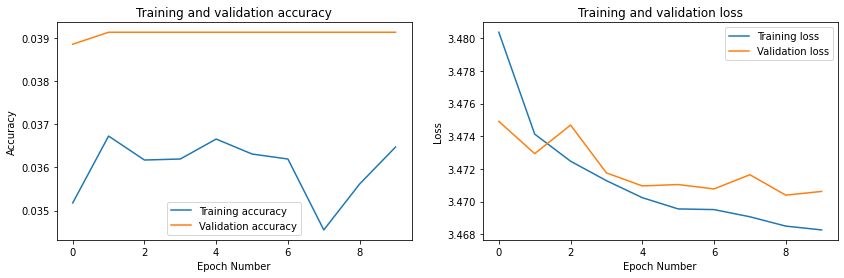

In [58]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Tanh activation function with RMSProp optimizer

In [59]:
model_tan_rm = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_sig.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_7 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_27 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_28 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_29 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_30 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [60]:
model_tan_rm.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
               metrics=['accuracy'])

In [61]:
# Training the model with 10 epochs
k = model_tan_rm.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 63s 92ms/step - loss: 3.4816 - accuracy: 0.0338 - val_loss: 3.4767 - val_accuracy: 0.0327
Epoch 2/10
676/676 [==============================] - 62s 92ms/step - loss: 3.4754 - accuracy: 0.0351 - val_loss: 3.4758 - val_accuracy: 0.0351
Epoch 3/10
676/676 [==============================] - 62s 92ms/step - loss: 3.4733 - accuracy: 0.0357 - val_loss: 3.4728 - val_accuracy: 0.0351
Epoch 4/10
676/676 [==============================] - 50s 73ms/step - loss: 3.4725 - accuracy: 0.0353 - val_loss: 3.4680 - val_accuracy: 0.0351
Epoch 5/10
676/676 [==============================] - 62s 91ms/step - loss: 3.4712 - accuracy: 0.0356 - val_loss: 3.4715 - val_accuracy: 0.0340
Epoch 6/10
676/676 [==============================] - 62s 92ms/step - loss: 3.4707 - accuracy: 0.0361 - val_loss: 3.4689 - val_accuracy: 0.0391
Epoch 7/10
676/676 [==============================] - 62s 92ms/step - loss: 3.4700 - accuracy: 0.0364 - val_loss: 3.4671 - val_accuracy:

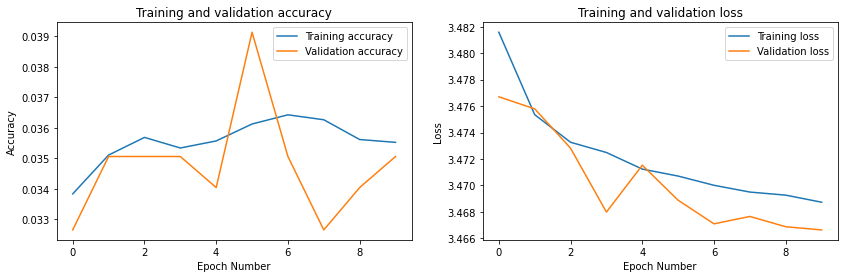

In [62]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Leaky ReLU activation function with SGD Momentum optimizer 

In [63]:
model_lr = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(64, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(64, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_lr.summary()

Model: "sequential_13"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_13 (Flatten)         (None, 150528)            0         
_________________________________________________________________
dense_51 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_52 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_53 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_54 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [64]:
model_lr.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
               metrics=['accuracy'])

In [65]:
# Training the model with 10 epochs
k = model_lr.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 49s 72ms/step - loss: 3.3984 - accuracy: 0.0662 - val_loss: 3.3553 - val_accuracy: 0.0729
Epoch 2/10
676/676 [==============================] - 62s 92ms/step - loss: 3.1912 - accuracy: 0.1186 - val_loss: 3.1403 - val_accuracy: 0.1348
Epoch 3/10
676/676 [==============================] - 50s 73ms/step - loss: 2.9813 - accuracy: 0.1668 - val_loss: 2.8749 - val_accuracy: 0.2034
Epoch 4/10
676/676 [==============================] - 61s 90ms/step - loss: 2.8061 - accuracy: 0.2109 - val_loss: 2.8075 - val_accuracy: 0.2117
Epoch 5/10
676/676 [==============================] - 63s 93ms/step - loss: 2.6602 - accuracy: 0.2500 - val_loss: 2.6588 - val_accuracy: 0.2478
Epoch 6/10
676/676 [==============================] - 63s 94ms/step - loss: 2.5271 - accuracy: 0.2875 - val_loss: 2.6756 - val_accuracy: 0.2437
Epoch 7/10
676/676 [==============================] - 49s 73ms/step - loss: 2.4161 - accuracy: 0.3139 - val_loss: 2.3505 - val_accuracy:

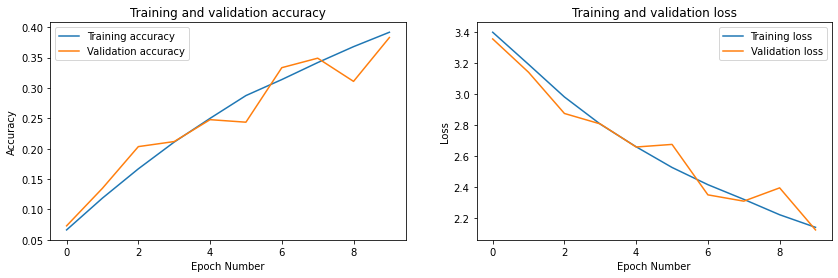

In [66]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Leaky ReLU activation function with Adam optimizer 

In [67]:
model_lr_a = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(64, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(64, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_lr_a.summary()

Model: "sequential_14"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_14 (Flatten)         (None, 150528)            0         
_________________________________________________________________
dense_55 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_56 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_57 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_58 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [68]:
model_lr_a.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
               metrics=['accuracy'])

In [69]:
# Training the model with 10 epochs
k = model_lr_a.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 62s 91ms/step - loss: 8.2195 - accuracy: 0.0757 - val_loss: 3.4521 - val_accuracy: 0.1220
Epoch 2/10
676/676 [==============================] - 49s 72ms/step - loss: 3.2421 - accuracy: 0.1526 - val_loss: 2.9678 - val_accuracy: 0.1844
Epoch 3/10
676/676 [==============================] - 63s 93ms/step - loss: 2.7850 - accuracy: 0.2392 - val_loss: 2.3872 - val_accuracy: 0.3152
Epoch 4/10
676/676 [==============================] - 63s 93ms/step - loss: 2.4912 - accuracy: 0.3053 - val_loss: 2.3328 - val_accuracy: 0.3366
Epoch 5/10
676/676 [==============================] - 63s 93ms/step - loss: 2.2631 - accuracy: 0.3574 - val_loss: 2.1910 - val_accuracy: 0.3870
Epoch 6/10
676/676 [==============================] - 54s 80ms/step - loss: 2.1718 - accuracy: 0.3858 - val_loss: 2.3962 - val_accuracy: 0.3547
Epoch 7/10
676/676 [==============================] - 63s 93ms/step - loss: 2.0575 - accuracy: 0.4116 - val_loss: 2.1126 - val_accuracy:

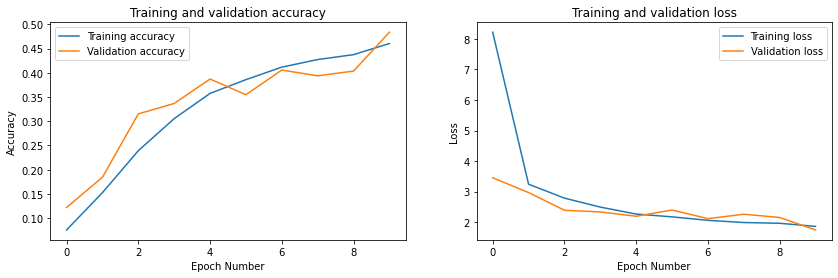

In [70]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q1 - 1- Asses the impact of Leaky ReLU activation function with RMSProp optimizer 

In [71]:
model_lr_rm = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224, 224,3,)),
    tf.keras.layers.Dense(128, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(64, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(64, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(32, activation='softmax')
])
model_sig.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_7 (Flatten)          (None, 150528)            0         
_________________________________________________________________
dense_27 (Dense)             (None, 128)               19267712  
_________________________________________________________________
dense_28 (Dense)             (None, 64)                8256      
_________________________________________________________________
dense_29 (Dense)             (None, 64)                4160      
_________________________________________________________________
dense_30 (Dense)             (None, 32)                2080      
Total params: 19,282,208
Trainable params: 19,282,208
Non-trainable params: 0
_________________________________________________________________


In [72]:
model_lr_rm.compile(loss='sparse_categorical_crossentropy',
               optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
               metrics=['accuracy'])

In [73]:
# Training the model with 10 epochs
k = model_lr_rm.fit(train_ds,
         validation_data=valid_ds,
         epochs=10)

Epoch 1/10
676/676 [==============================] - 63s 93ms/step - loss: 43.2894 - accuracy: 0.0360 - val_loss: 14.3363 - val_accuracy: 0.0607
Epoch 2/10
676/676 [==============================] - 63s 93ms/step - loss: 15.2955 - accuracy: 0.0437 - val_loss: 6.9917 - val_accuracy: 0.0411
Epoch 3/10
676/676 [==============================] - 63s 93ms/step - loss: 11.4857 - accuracy: 0.0529 - val_loss: 9.3097 - val_accuracy: 0.0428
Epoch 4/10
676/676 [==============================] - 63s 93ms/step - loss: 9.9803 - accuracy: 0.0609 - val_loss: 3.5594 - val_accuracy: 0.0727
Epoch 5/10
676/676 [==============================] - 50s 73ms/step - loss: 8.4190 - accuracy: 0.0706 - val_loss: 5.9519 - val_accuracy: 0.0811
Epoch 6/10
676/676 [==============================] - 64s 94ms/step - loss: 8.1637 - accuracy: 0.0797 - val_loss: 3.4862 - val_accuracy: 0.1345
Epoch 7/10
676/676 [==============================] - 64s 94ms/step - loss: 6.9796 - accuracy: 0.0982 - val_loss: 6.0708 - val_accur

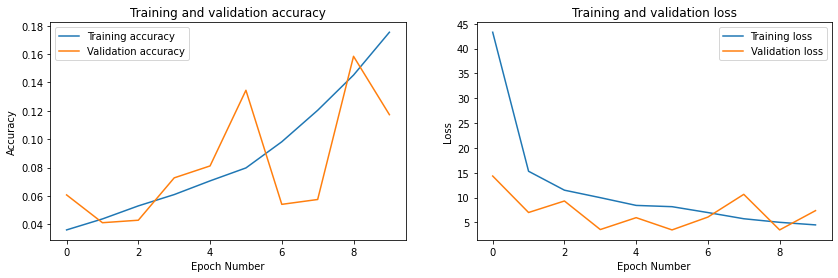

In [74]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(k.history['accuracy'])
plt.plot(k.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(k.history['loss'])
plt.plot(k.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

# Question 2 CNN

### Q2 1- Asses the impact of Relu activation function with Adam optimizer

In [26]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_re_ad1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [27]:
model_re_ad1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              metrics=['accuracy'])

model_re_ad1_f = model_re_ad1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 71s 104ms/step - loss: 1.8480 - accuracy: 0.5032 - val_loss: 0.8841 - val_accuracy: 0.7759
Epoch 2/5
676/676 [==============================] - 69s 102ms/step - loss: 0.5891 - accuracy: 0.8455 - val_loss: 0.5051 - val_accuracy: 0.8818
Epoch 3/5
676/676 [==============================] - 70s 104ms/step - loss: 0.2876 - accuracy: 0.9220 - val_loss: 0.3802 - val_accuracy: 0.9157
Epoch 4/5
676/676 [==============================] - 70s 103ms/step - loss: 0.1695 - accuracy: 0.9515 - val_loss: 0.3763 - val_accuracy: 0.9266
Epoch 5/5
676/676 [==============================] - 55s 81ms/step - loss: 0.1273 - accuracy: 0.9623 - val_loss: 0.4163 - val_accuracy: 0.9227


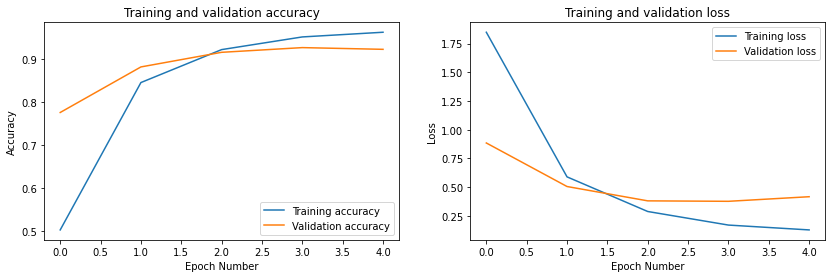

In [28]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_re_ad1_f.history['accuracy'])
plt.plot(model_re_ad1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_re_ad1_f.history['loss'])
plt.plot(model_re_ad1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Relu activation function with SGD Momentum optimizer

In [29]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_re_sgd1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [30]:
model_re_sgd1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
              metrics=['accuracy'])

model_re_sgd1_f = model_re_sgd1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 69s 101ms/step - loss: 3.4576 - accuracy: 0.0426 - val_loss: 3.4279 - val_accuracy: 0.0564
Epoch 2/5
676/676 [==============================] - 68s 100ms/step - loss: 3.4077 - accuracy: 0.0614 - val_loss: 3.3468 - val_accuracy: 0.0801
Epoch 3/5
676/676 [==============================] - 68s 101ms/step - loss: 3.3051 - accuracy: 0.0883 - val_loss: 3.2038 - val_accuracy: 0.1154
Epoch 4/5
676/676 [==============================] - 68s 101ms/step - loss: 3.1322 - accuracy: 0.1285 - val_loss: 2.9674 - val_accuracy: 0.1701
Epoch 5/5
676/676 [==============================] - 54s 79ms/step - loss: 2.9333 - accuracy: 0.1792 - val_loss: 2.7531 - val_accuracy: 0.2267


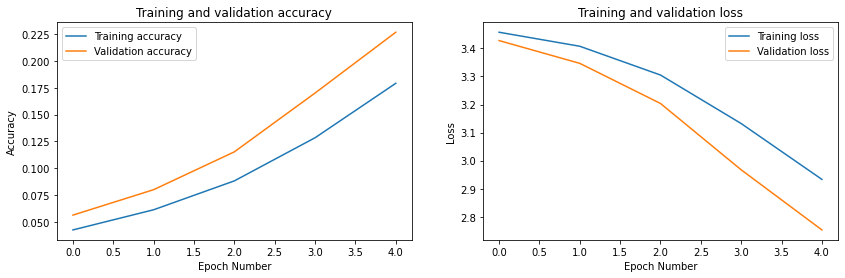

In [31]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_re_sgd1_f.history['accuracy'])
plt.plot(model_re_sgd1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_re_sgd1_f.history['loss'])
plt.plot(model_re_sgd1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Relu activation function with RMSProp optimizer

In [32]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_r_rm1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [33]:
model_r_rm1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
              metrics=['accuracy'])

model_r_rm1_f = model_r_rm1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 69s 102ms/step - loss: 2.0532 - accuracy: 0.4507 - val_loss: 1.6985 - val_accuracy: 0.5264
Epoch 2/5
676/676 [==============================] - 68s 100ms/step - loss: 0.7472 - accuracy: 0.8112 - val_loss: 0.5433 - val_accuracy: 0.8660
Epoch 3/5
676/676 [==============================] - 68s 100ms/step - loss: 0.4482 - accuracy: 0.8967 - val_loss: 0.7817 - val_accuracy: 0.8005
Epoch 4/5
676/676 [==============================] - 68s 101ms/step - loss: 0.2924 - accuracy: 0.9297 - val_loss: 0.4725 - val_accuracy: 0.9073
Epoch 5/5
676/676 [==============================] - 54s 80ms/step - loss: 0.2662 - accuracy: 0.9486 - val_loss: 0.4764 - val_accuracy: 0.9135


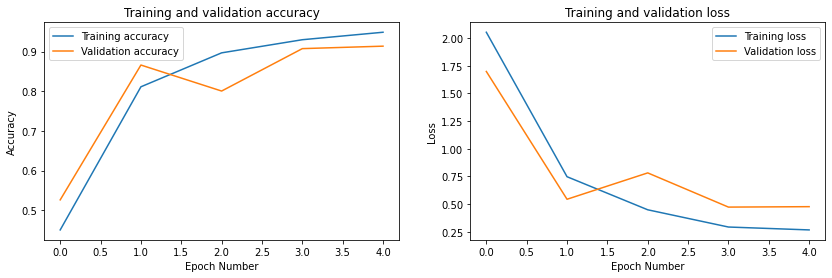

In [34]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_r_rm1_f.history['accuracy'])
plt.plot(model_r_rm1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_r_rm1_f.history['loss'])
plt.plot(model_r_rm1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Sigmoid activation function with SGD Momentum optimizer

In [35]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_si_sgd1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='sigmoid',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='sigmoid'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [36]:
model_si_sgd1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
              metrics=['accuracy'])

model_si_sgd1_f = model_si_sgd1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 69s 101ms/step - loss: 3.4780 - accuracy: 0.0342 - val_loss: 3.4630 - val_accuracy: 0.0391
Epoch 2/5
676/676 [==============================] - 68s 100ms/step - loss: 3.4686 - accuracy: 0.0360 - val_loss: 3.4617 - val_accuracy: 0.0391
Epoch 3/5
676/676 [==============================] - 68s 100ms/step - loss: 3.4663 - accuracy: 0.0352 - val_loss: 3.4608 - val_accuracy: 0.0391
Epoch 4/5
676/676 [==============================] - 68s 100ms/step - loss: 3.4649 - accuracy: 0.0364 - val_loss: 3.4603 - val_accuracy: 0.0391
Epoch 5/5
676/676 [==============================] - 55s 81ms/step - loss: 3.4628 - accuracy: 0.0383 - val_loss: 3.4601 - val_accuracy: 0.0391


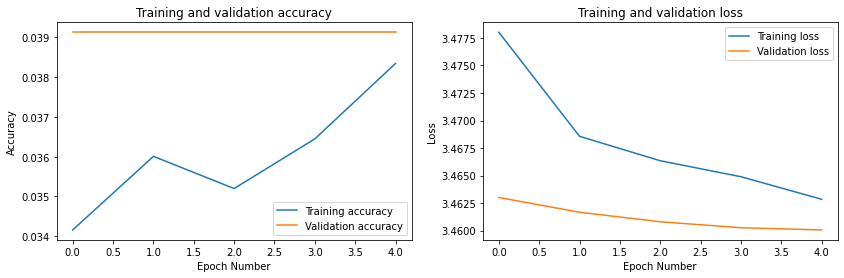

In [37]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_si_sgd1_f.history['accuracy'])
plt.plot(model_si_sgd1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_si_sgd1_f.history['loss'])
plt.plot(model_si_sgd1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Sigmoid activation function with Adam optimizer

In [38]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_sig_ad1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='sigmoid',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='sigmoid'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [39]:
model_sig_ad1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              metrics=['accuracy'])

model_sig_ad1_f = model_sig_ad1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 69s 101ms/step - loss: 3.4785 - accuracy: 0.0353 - val_loss: 3.4688 - val_accuracy: 0.0391
Epoch 2/5
676/676 [==============================] - 69s 101ms/step - loss: 3.4674 - accuracy: 0.0360 - val_loss: 3.4689 - val_accuracy: 0.0391
Epoch 3/5
676/676 [==============================] - 68s 100ms/step - loss: 3.4673 - accuracy: 0.0353 - val_loss: 3.4689 - val_accuracy: 0.0391
Epoch 4/5
676/676 [==============================] - 68s 101ms/step - loss: 3.4674 - accuracy: 0.0354 - val_loss: 3.4693 - val_accuracy: 0.0391
Epoch 5/5
676/676 [==============================] - 55s 82ms/step - loss: 3.4675 - accuracy: 0.0357 - val_loss: 3.4691 - val_accuracy: 0.0391


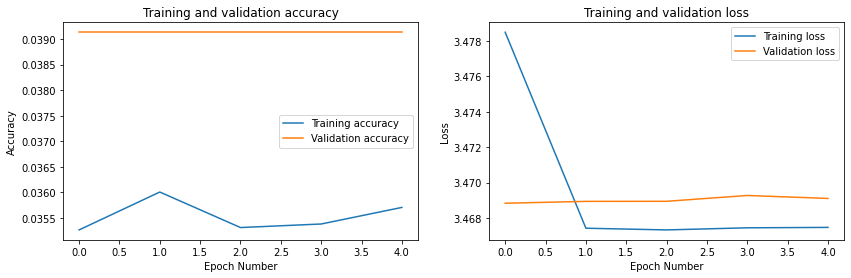

In [40]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_sig_ad1_f.history['accuracy'])
plt.plot(model_sig_ad1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_sig_ad1_f.history['loss'])
plt.plot(model_sig_ad1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Sigmoid activation function with RMSProp optimizer

In [41]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_sig_rms1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='sigmoid',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='sigmoid'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [42]:
model_sig_rms1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
              metrics=['accuracy'])

model_sig_rms1_f = model_sig_rms1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 70s 103ms/step - loss: 3.4787 - accuracy: 0.0366 - val_loss: 3.4677 - val_accuracy: 0.0391
Epoch 2/5
676/676 [==============================] - 69s 101ms/step - loss: 3.4696 - accuracy: 0.0360 - val_loss: 3.4676 - val_accuracy: 0.0327
Epoch 3/5
676/676 [==============================] - 68s 101ms/step - loss: 3.4695 - accuracy: 0.0356 - val_loss: 3.4670 - val_accuracy: 0.0391
Epoch 4/5
676/676 [==============================] - 69s 102ms/step - loss: 3.4694 - accuracy: 0.0360 - val_loss: 3.4685 - val_accuracy: 0.0391
Epoch 5/5
676/676 [==============================] - 56s 82ms/step - loss: 3.4695 - accuracy: 0.0359 - val_loss: 3.4680 - val_accuracy: 0.0391


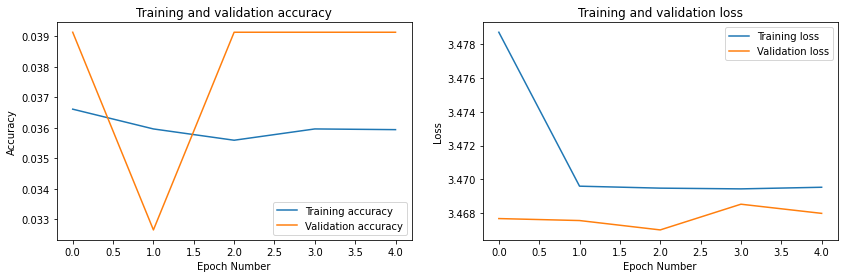

In [43]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_sig_rms1_f.history['accuracy'])
plt.plot(model_sig_rms1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_sig_rms1_f.history['loss'])
plt.plot(model_sig_rms1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Tanh activation function with SGD Momentum optimizer

In [44]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_tan_sgd1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='tanh',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='tanh'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [45]:
model_tan_sgd1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
              metrics=['accuracy'])

model_tan_sgd1_f = model_tan_sgd1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 68s 100ms/step - loss: 3.4541 - accuracy: 0.0517 - val_loss: 3.3780 - val_accuracy: 0.0717
Epoch 2/5
676/676 [==============================] - 68s 100ms/step - loss: 3.3513 - accuracy: 0.0839 - val_loss: 3.2775 - val_accuracy: 0.0895
Epoch 3/5
676/676 [==============================] - 68s 101ms/step - loss: 3.2402 - accuracy: 0.1144 - val_loss: 3.1246 - val_accuracy: 0.1442
Epoch 4/5
676/676 [==============================] - 68s 100ms/step - loss: 3.0991 - accuracy: 0.1517 - val_loss: 2.9788 - val_accuracy: 0.1881
Epoch 5/5
676/676 [==============================] - 54s 79ms/step - loss: 2.9447 - accuracy: 0.1920 - val_loss: 2.8257 - val_accuracy: 0.2236


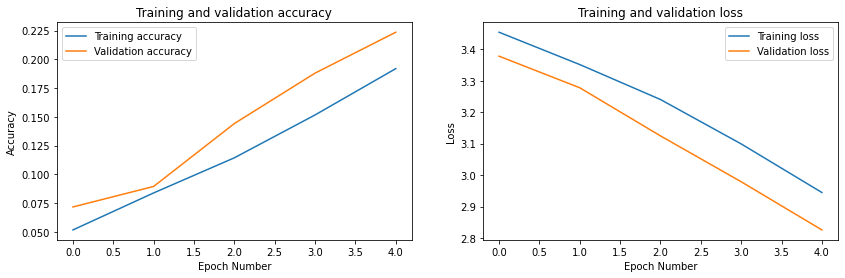

In [46]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_tan_sgd1_f.history['accuracy'])
plt.plot(model_tan_sgd1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_tan_sgd1_f.history['loss'])
plt.plot(model_tan_sgd1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Tanh activation function with Adam optimizer

In [47]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_tan_ad1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='tanh',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='tanh'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [48]:
model_tan_ad1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              metrics=['accuracy'])

model_tan_ad1_f = model_tan_ad1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 68s 100ms/step - loss: 3.5263 - accuracy: 0.0366 - val_loss: 3.4644 - val_accuracy: 0.0454
Epoch 2/5
676/676 [==============================] - 68s 100ms/step - loss: 3.4724 - accuracy: 0.0387 - val_loss: 3.4767 - val_accuracy: 0.0391
Epoch 3/5
676/676 [==============================] - 68s 101ms/step - loss: 3.4814 - accuracy: 0.0346 - val_loss: 3.4786 - val_accuracy: 0.0340
Epoch 4/5
676/676 [==============================] - 68s 100ms/step - loss: 3.4813 - accuracy: 0.0343 - val_loss: 3.4764 - val_accuracy: 0.0391
Epoch 5/5
676/676 [==============================] - 70s 103ms/step - loss: 3.4811 - accuracy: 0.0344 - val_loss: 3.4745 - val_accuracy: 0.0391


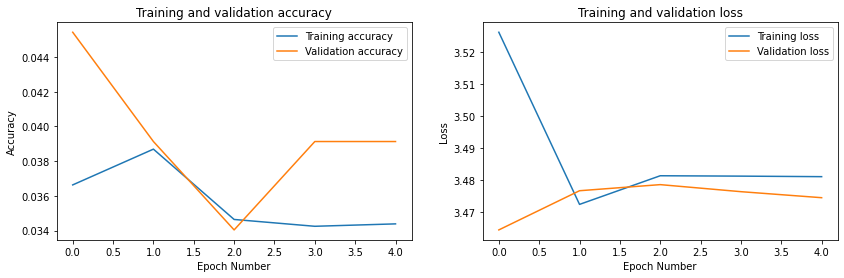

In [49]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_tan_ad1_f.history['accuracy'])
plt.plot(model_tan_ad1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_tan_ad1_f.history['loss'])
plt.plot(model_tan_ad1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Tanh activation function with RMSProp optimizer

In [50]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_tan_rmsp1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='tanh',
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='tanh'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='tanh'),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [51]:
model_tan_rmsp1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
              metrics=['accuracy'])

model_tan_rmsp1_f = model_tan_rmsp1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 57s 83ms/step - loss: 3.5152 - accuracy: 0.0334 - val_loss: 3.4841 - val_accuracy: 0.0351
Epoch 2/5
676/676 [==============================] - 69s 102ms/step - loss: 3.4834 - accuracy: 0.0339 - val_loss: 3.4855 - val_accuracy: 0.0351
Epoch 3/5
676/676 [==============================] - 69s 102ms/step - loss: 3.4828 - accuracy: 0.0340 - val_loss: 3.4849 - val_accuracy: 0.0351
Epoch 4/5
676/676 [==============================] - 69s 101ms/step - loss: 3.4834 - accuracy: 0.0338 - val_loss: 3.4791 - val_accuracy: 0.0327
Epoch 5/5
676/676 [==============================] - 69s 103ms/step - loss: 3.4832 - accuracy: 0.0333 - val_loss: 3.4800 - val_accuracy: 0.0327


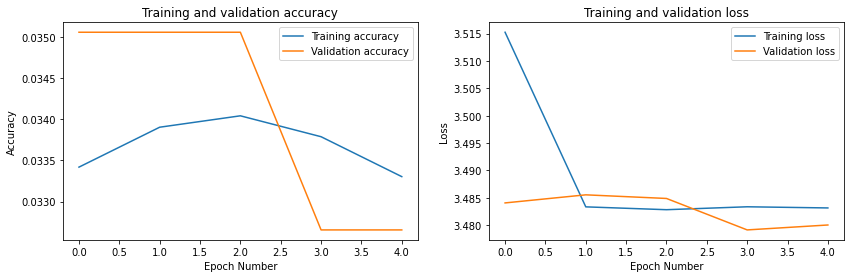

In [52]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_tan_rmsp1_f.history['accuracy'])
plt.plot(model_tan_rmsp1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_tan_rmsp1_f.history['loss'])
plt.plot(model_tan_rmsp1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Leaky ReLU activation function with SGD Momentum optimizer

In [53]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_lr_sgd1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.leaky_relu,
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.leaky_relu),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [54]:
model_lr_sgd1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
              metrics=['accuracy'])

model_lr_sgd1_f = model_lr_sgd1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 55s 80ms/step - loss: 3.4558 - accuracy: 0.0455 - val_loss: 3.4253 - val_accuracy: 0.0573
Epoch 2/5
676/676 [==============================] - 55s 80ms/step - loss: 3.4024 - accuracy: 0.0660 - val_loss: 3.3388 - val_accuracy: 0.0825
Epoch 3/5
676/676 [==============================] - 68s 100ms/step - loss: 3.3140 - accuracy: 0.0908 - val_loss: 3.2098 - val_accuracy: 0.1191
Epoch 4/5
676/676 [==============================] - 67s 99ms/step - loss: 3.1872 - accuracy: 0.1201 - val_loss: 3.0609 - val_accuracy: 0.1529
Epoch 5/5
676/676 [==============================] - 68s 100ms/step - loss: 3.0416 - accuracy: 0.1574 - val_loss: 2.8959 - val_accuracy: 0.2035


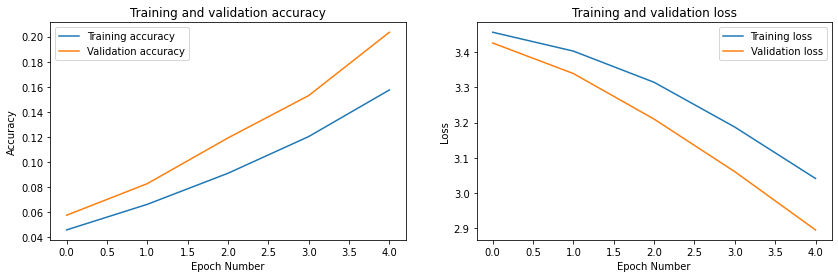

In [55]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_lr_sgd1_f.history['accuracy'])
plt.plot(model_lr_sgd1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_lr_sgd1_f.history['loss'])
plt.plot(model_lr_sgd1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Leaky ReLU activation function with Adam optimizer

In [56]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_lr_ad1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.leaky_relu,
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.leaky_relu),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [57]:
model_lr_ad1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              metrics=['accuracy'])

model_lr_ad1_f = model_lr_ad1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 55s 81ms/step - loss: 2.5260 - accuracy: 0.3347 - val_loss: 1.1086 - val_accuracy: 0.6919
Epoch 2/5
676/676 [==============================] - 68s 100ms/step - loss: 0.7811 - accuracy: 0.7876 - val_loss: 0.5615 - val_accuracy: 0.8592
Epoch 3/5
676/676 [==============================] - 67s 99ms/step - loss: 0.4163 - accuracy: 0.8870 - val_loss: 0.4364 - val_accuracy: 0.8909
Epoch 4/5
676/676 [==============================] - 68s 100ms/step - loss: 0.2774 - accuracy: 0.9232 - val_loss: 0.4110 - val_accuracy: 0.9090
Epoch 5/5
676/676 [==============================] - 68s 101ms/step - loss: 0.2142 - accuracy: 0.9358 - val_loss: 0.4245 - val_accuracy: 0.9063


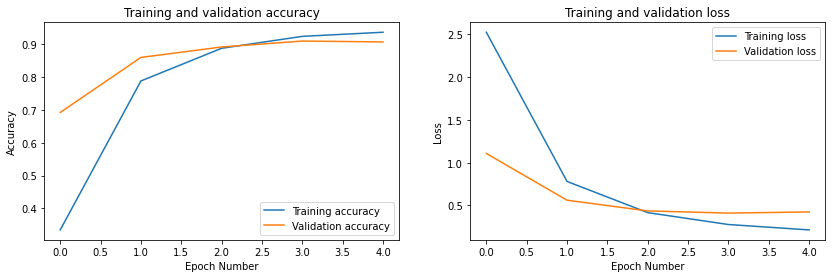

In [58]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_lr_ad1_f.history['accuracy'])
plt.plot(model_lr_ad1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_lr_ad1_f.history['loss'])
plt.plot(model_lr_ad1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

### Q2 1- Asses the impact of Leaky ReLU activation function with RMSProp optimizer

In [59]:
# Build CNN model function with 2 Pool, 2 Conv, 32 filter and stride 2
# Model contain 2D Convolution Layer with Kernal size (3*3)
# Activation function
# Dropout layer by 50% for Reguraliztion 

model_lr_rmsp1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.leaky_relu,
                           input_shape=(224, 224, 3,)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.leaky_relu),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dense(32,  activation='softmax')
    ]) 

In [60]:
model_lr_rmsp1.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3),
              metrics=['accuracy'])

model_lr_rmsp1_f = model_lr_rmsp1.fit(train_ds,
          validation_data=valid_ds,
          epochs=5)

Epoch 1/5
676/676 [==============================] - 54s 80ms/step - loss: 2.9488 - accuracy: 0.2973 - val_loss: 1.6029 - val_accuracy: 0.5204
Epoch 2/5
676/676 [==============================] - 68s 100ms/step - loss: 0.9605 - accuracy: 0.7363 - val_loss: 0.6866 - val_accuracy: 0.8239
Epoch 3/5
676/676 [==============================] - 68s 100ms/step - loss: 0.4812 - accuracy: 0.8723 - val_loss: 0.4886 - val_accuracy: 0.8855
Epoch 4/5
676/676 [==============================] - 68s 101ms/step - loss: 0.2979 - accuracy: 0.9192 - val_loss: 0.5202 - val_accuracy: 0.8855
Epoch 5/5
676/676 [==============================] - 68s 100ms/step - loss: 0.2040 - accuracy: 0.9423 - val_loss: 0.5971 - val_accuracy: 0.8814


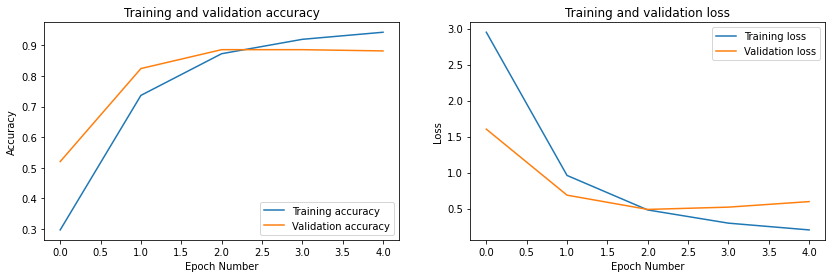

In [61]:
# Accuracy and loss values figures
fig = plt.figure(figsize=(14,4))
fig.add_subplot(121)
plt.plot(model_lr_rmsp1_f.history['accuracy'])
plt.plot(model_lr_rmsp1_f.history['val_accuracy'])
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.title('Training and validation accuracy')
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')

# Loss Figure
fig.add_subplot(122)
plt.plot(model_lr_rmsp1_f.history['loss'])
plt.plot(model_lr_rmsp1_f.history['val_loss'])
plt.legend(['Training loss', 'Validation loss'])
plt.title('Training and validation loss')
plt.xlabel('Epoch Number')
plt.ylabel('Loss')

plt.show()

# Conclusion

This project compared fully connected and convolutional architectures across ReLU, sigmoid, tanh, and Leaky ReLU activations with SGD, Adam, and RMSprop optimizers.

## Recorded findings

1. Adding an additional dense hidden layer improved the reported result substantially, although the fully connected models remained less effective for this image task.
2. ReLU with Adam produced the strongest fully connected result in the comparison table.
3. The convolutional models performed substantially better. ReLU with Adam recorded 96.23% training accuracy and 92.27% validation accuracy after five epochs in the preserved run.
4. Some activation and optimizer combinations showed underfitting or widening training-validation gaps. The learning curves preserved above should be used when interpreting the summary tables.

These are results from the original course experiment, not an independently reproduced benchmark or a held-out external test evaluation.


In [ ]:
from IPython.display import Image, display
display(Image(filename=str(ASSETS_DIR / "fully_connected_accuracy.png")))


In [ ]:
from IPython.display import Image, display
display(Image(filename=str(ASSETS_DIR / "cnn_accuracy.png")))


#### 4- Noticed that while training using Leaky Relu activation and RMSprop optimizer the model at some time the model was overfittied, the figure shows that the training accuracy increasing and validation accuracy is decreasing.

In [ ]:
# Refer to the preserved CNN learning curves above for the overfitting discussion.


#### 5- In NN noticed that the model that used ('Relu','SGD') was suffering from underfitting due to there is no gap between training accuracy and validation accuracy as the below figure shows.

In [ ]:
# Refer to the preserved dense-model learning curves above for the underfitting discussion.
